# Programming Assignment 1

Segmentação de instâncias com as arquiteturas da aula

Equipe: Jaime Willian Carneiro da Silva & Luiz Eduardo Bravin

In [1]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, random_split, Dataset
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time

## Datasets 

Escolheremos a opção A - DSB2018 / BBBC038v1

Download:  https://bbbc.broadinstitute.org/BBBC038

In [2]:
def generate_image(img_size: int, seed: int = None):
    image = np.zeros((img_size, img_size, 3), dtype= np.uint8)
    rng = np.random.default_rng(seed=seed)
    num_ellipses = int(rng.integers(5, 21))
    instance_masks = np.zeros((num_ellipses, img_size, img_size), dtype= np.uint8)
    
    for idx in range(num_ellipses):
        center = tuple(rng.integers(0, img_size + 1, size=2).tolist())
        axes = tuple(rng.integers(5, 41, size=2).tolist())
        angle = int(rng.integers(0, 101))
        color = tuple(rng.integers(50, 256, size=3).tolist())
    
        cv.ellipse(image, center, axes, angle, 0, 360, color, -1)
        cv.ellipse(instance_masks[idx], center, axes, angle, 0, 360, 1, -1)
        
    contrast = rng.random() + 0.5
    noise = rng.integers(-20, 20, size=(img_size, img_size, 3))
    image = (image * contrast) + noise
    image = np.clip(image, 0 , 255 ).astype(np.uint8)

    return image, instance_masks


def to_tensors(image: np.ndarray, instance_masks: np.ndarray):
    image_tensor = torch.from_numpy(image.transpose((2, 0, 1))).float() / 255.0

    binary_mask = (instance_masks.sum(axis=0) > 0).astype(np.float32)
    binary_mask_tensor = torch.from_numpy(binary_mask).unsqueeze(0)

    instance_gt = np.zeros(instance_masks.shape[1:], dtype=np.int32)
    for i, mask in enumerate(instance_masks):
        instance_gt[mask > 0] = i + 1
        
    return image_tensor, binary_mask_tensor, instance_gt


In [3]:
class SyntheticEllipseDataset(Dataset):
    def __init__(self, num_samples: int, img_size: int = 128, seed: int = None) -> None:
        super().__init__()
        self.num_samples = num_samples
        self.img_size = img_size
        self.seed = seed

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        seed = None if self.seed is None else self.seed + idx
        image, instance_masks = generate_image(self.img_size, seed=seed)            
        return to_tensors(image, instance_masks)


class DSB2018Dataset(Dataset):
    def __init__(self, root_dir: str, img_size: int = 128, sample_ids: list = None):
        super().__init__()
        self.root_dir = Path(root_dir)
        self.img_size = img_size
        self.sample_ids = sample_ids or sorted(
            p.name for p in self.root_dir.iterdir() if p.is_dir()
        )

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sample_dir = self.root_dir / self.sample_ids[idx]

        image_path = next((sample_dir / "images").glob("*.png"))
        image = cv.imread(str(image_path), cv.IMREAD_COLOR)
        image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
        image = cv.resize(image, (self.img_size, self.img_size), interpolation=cv.INTER_LINEAR)

        mask_paths = sorted((sample_dir / "masks").glob("*.png"))
        instance_masks = np.zeros((len(mask_paths), self.img_size, self.img_size), dtype=np.uint8)
        for i, mask_path in enumerate(mask_paths):
            mask = cv.imread(str(mask_path), cv.IMREAD_GRAYSCALE)
            mask = cv.resize(mask, (self.img_size, self.img_size), interpolation=cv.INTER_NEAREST)
            instance_masks[i] = (mask > 127).astype(np.uint8)

        return to_tensors(image, instance_masks)

In [4]:
def build_dataset(dataset_type: str, **kwargs):
    if dataset_type == "synthetic":
        return SyntheticEllipseDataset(**kwargs)
    elif dataset_type == "real":
        return DSB2018Dataset(**kwargs)

## Modelo

In [5]:
class UNetBinary(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        
        # ENCODER
        self.enc1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu) # 64x64
        self.pool = resnet.maxpool # 32x32
        self.enc2 = resnet.layer1  # 32x32, 64 canais
        self.enc3 = resnet.layer2  # 16x16, 128 canais
        self.enc4 = resnet.layer3  # 8x8, 256 canais

        # DECODER
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(nn.Conv2d(256, 128, kernel_size=3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU())
        self.up0 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, 1, kernel_size=1) # Saída de 1 canal

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(x2)
        x4 = self.enc4(x3)

        d3 = self.dec3(torch.cat([self.up3(x4), x3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), x2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), x1], dim=1))
        
        return self.final_conv(self.up0(d1))


def train_model(model, dataloader, device, lr=1e-3, num_epochs=5):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    num_batchs = len(dataloader)

    for epoch in range(num_epochs):
        model.train()
        accumulated_loss = 0.0
        total_intersection = 0.0
        total_union = 0.0
        
        for images, masks, _ in dataloader:
            images = images.to(device)
            masks = masks.to(device)
            
            optimizer.zero_grad()
            prediction = model(images)
            loss = criterion(prediction, masks)
            loss.backward()
            optimizer.step()

            binary_prediction = (torch.sigmoid(prediction) > 0.5).float()
            intersection = (binary_prediction * masks).sum()
            union = binary_prediction.sum() + masks.sum() - intersection
            
            accumulated_loss += loss.item()
            total_intersection += intersection.item()
            total_union += union.item()

        epoch_iou = total_intersection / (total_union + 1e-6)
        epoch_dice = (2.0 * total_intersection) / (total_union + total_intersection + 1e-6)
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {accumulated_loss/num_batchs:.4f} | Semantic IoU: {epoch_iou:.4f} | Dice: {epoch_dice:.4f}")


## Métricas

A regra de matching utilizada foi a guloso por IoU.

In [42]:
def calculate_instance_metrics(true_instances, pred_binary):
    pred_binary = np.squeeze(pred_binary)
    pred_instances = cv.connectedComponents(pred_binary.astype(np.uint8))[1]
    true_ids = np.unique(true_instances)[1:] # Remove the background label (0)
    pred_ids = np.unique(pred_instances)[1:] # Remove the background label (0)

    # Absolute count error
    num_true_objects = len(true_ids)
    num_pred_objects = len(pred_ids)
    count_error = abs(num_pred_objects - num_true_objects)

    # Extreme cases: no objects in either true or predicted masks
    if num_true_objects == 0 and num_pred_objects == 0:
        return 1.0, count_error, num_true_objects
    if num_true_objects == 0 or num_pred_objects == 0:
        return 0.0, count_error, num_true_objects

    # IoU Matrix Calculation
    iou_matrix = np.zeros((num_true_objects, num_pred_objects))
    for i, t_id in enumerate(true_ids):
        t_mask = (true_instances == t_id)
        for j, p_id in enumerate(pred_ids):
            p_mask = (pred_instances == p_id)
            
            intersection = np.logical_and(t_mask, p_mask).sum()
            if intersection > 0:
                union = np.logical_or(t_mask, p_mask).sum()
                iou_matrix[i, j] = intersection / union

    sorted_indices = np.argsort( iou_matrix.flatten())[::-1]
    shape = iou_matrix.shape
    #  Calculate Average Precision 
    aps = []
    for t in np.arange(0.5, 1.0, 0.05):
        tp = 0
        matched_true = set()
        matched_pred = set()
        
        for idx in sorted_indices:
            t_idx, p_idx = np.unravel_index(idx, shape)
            iou = iou_matrix[t_idx, p_idx]
            if iou < t:
                break
            
            if t_idx not in matched_true and p_idx not in matched_pred:
                tp += 1 # só os diferentes
                matched_true.add(t_idx)
                matched_pred.add(p_idx)
                
        fp = num_pred_objects - tp
        fn = num_true_objects - tp
        ap = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
        aps.append(ap)
        
    mAP = np.mean(aps)
    
    return mAP, count_error, num_true_objects



def evaluate(model, dataloader, device):
    model.eval()
    all_mAPs = []
    all_count_errors = []
    all_densities = []

    for images, _, real_instances in dataloader:
        with torch.no_grad():
            binary_preds = (torch.sigmoid(model(images.to(device))) > 0.5).float().cpu().numpy()

        real_instances = real_instances.numpy()

        for i in range(images.size(0)):
            mAP, count_error, density = calculate_instance_metrics(
                real_instances[i],
                binary_preds[i, 0]
            )
            all_mAPs.append(mAP)
            all_count_errors.append(count_error)
            all_densities.append(density)

    return all_mAPs, all_count_errors, all_densities


def plot_metrics(all_mAPs, all_count_errors, all_densities):
    """Imprime as médias globais e plota os gráficos de falha baseados na densidade."""
    print(f"Média global mAP: {np.mean(all_mAPs):.4f}")
    print(f"Média global Erro Absoluto de Contagem: {np.mean(all_count_errors):.4f}")

    fig, ax = plt.subplots(1, 2, figsize=(10, 6))

    color = 'tab:blue'
    ax[0].set_xlabel('Densidade de Objetos (Qtd. de Instâncias Reais)')
    ax[0].set_ylabel('mAP (Threshold 0.5 a 0.95)', color=color)
    ax[0].scatter(all_densities, all_mAPs, color=color, alpha=0.6, label='mAP')
    ax[0].tick_params(axis='y', labelcolor=color)
    ax[0].spines['right'].set_visible(False)
    ax[0].spines['top'].set_visible(False)
    ax[0].set_title("Quantificação de Falhas: Desempenho vs. Densidade", fontsize = 10, fontweight='bold')

    color = 'tab:red'
    ax[1].set_ylabel('Erro Absoluto de Contagem', color=color)
    ax[1].scatter(all_densities, all_count_errors, color=color, alpha=0.6, label='Erro de Contagem')
    ax[1].set_xlabel('Densidade de Objetos (Qtd. de Instâncias Reais)')
    ax[1].tick_params(axis='y', labelcolor=color)
    ax[1].spines['right'].set_visible(False)
    ax[1].spines['top'].set_visible(False)
    ax[1].set_title("Quantificação de Falhas: Desempenho vs. Densidade", fontsize = 10,  fontweight='bold')
    plt.grid(False)
    fig.tight_layout()
    plt.show()

Parte 0 - Teste Unitário

Synthetic Train: 536, Synthetic Val: 134, Synthetic Test: 65
Epoch 1/6 | Loss: 0.1549 | Semantic IoU: 0.8982 | Dice: 0.9464
Epoch 2/6 | Loss: 0.0292 | Semantic IoU: 0.9817 | Dice: 0.9908
Epoch 3/6 | Loss: 0.0139 | Semantic IoU: 0.9928 | Dice: 0.9964
Epoch 4/6 | Loss: 0.0126 | Semantic IoU: 0.9932 | Dice: 0.9966
Epoch 5/6 | Loss: 0.0087 | Semantic IoU: 0.9954 | Dice: 0.9977
Epoch 6/6 | Loss: 0.0035 | Semantic IoU: 0.9986 | Dice: 0.9993
Training time: 2.76 minutes
Média global mAP: 0.0905
Média global Erro Absoluto de Contagem: 9.3881


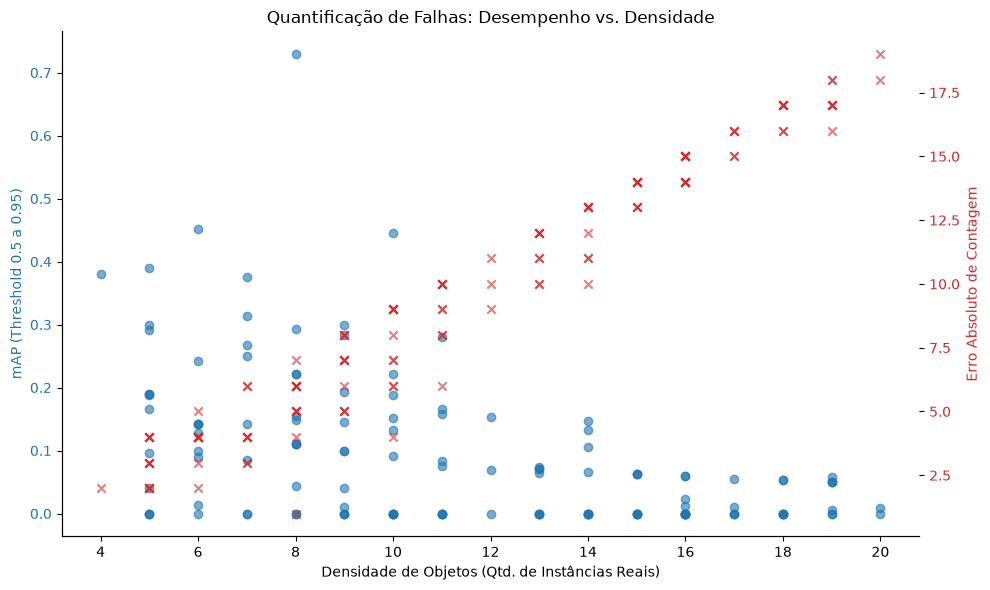

In [7]:
# Created the synthetic images 
synthetic_train = build_dataset("synthetic", num_samples=536, img_size=128)
synthetic_val = build_dataset("synthetic", num_samples=134, img_size=128)
synthetic_test = build_dataset("synthetic", num_samples=65, img_size=128)
print(f"Synthetic Train: {len(synthetic_train)}, Synthetic Val: {len(synthetic_val)}, Synthetic Test: {len(synthetic_test)}")

# Create data loaders
synthetic_train_loader = DataLoader(synthetic_train, batch_size=8, shuffle=True)
synthetic_val_loader = DataLoader(synthetic_val, batch_size=8, shuffle=False)
synthetic_test_loader = DataLoader(synthetic_test, batch_size=8, shuffle=False)

# Train and evaluate the model
synthetic_model = UNetBinary()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
start = time.time()
train_model(synthetic_model, synthetic_train_loader, device, num_epochs=6)
print(f"Training time: {(time.time() - start) / 60:.2f} minutes")


Média global mAP: 0.0901
Média global Erro Absoluto de Contagem: 9.6418


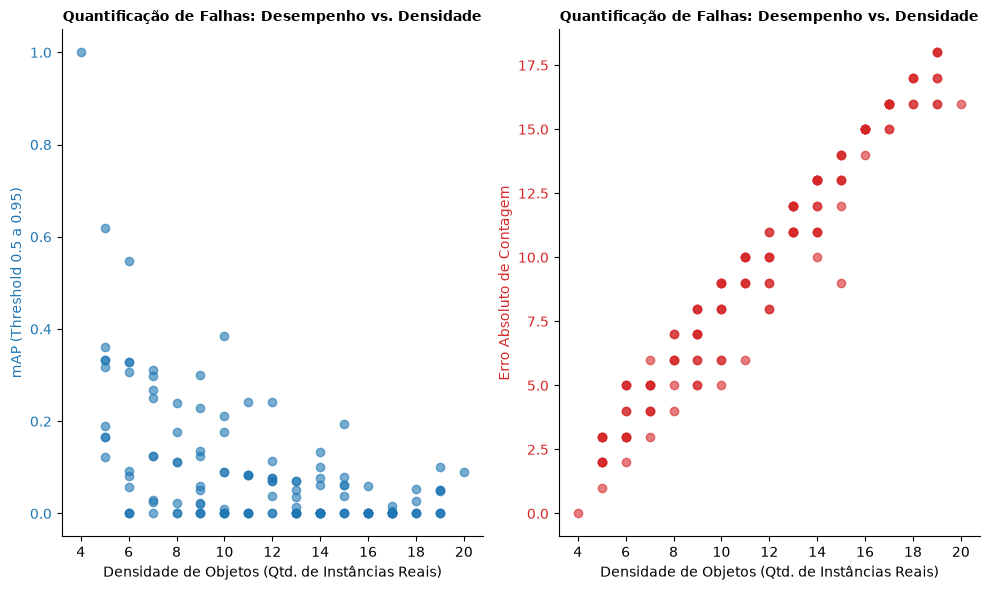

In [43]:
plot_metrics(*evaluate(synthetic_model, synthetic_val_loader, device))


Quanto maior a quantidade de elipses, maior facilidade de ter intersecção entre elas. Com isso, o modelo interpreta como se fosse apenas um objeto, logo diminuindo o mAP e aumentando o erro absoluto de contagem. 

Parte 1

In [9]:
# Extracted and formatted the images 
real_train_val = build_dataset("real", root_dir="./data/stage1_train", img_size=128)
real_train, real_val = random_split(real_train_val, [int(0.8 * len(real_train_val)), int(0.2 * len(real_train_val))])
real_test = build_dataset("real", root_dir="./data/stage1_test", img_size=128)
print(f"Real Train: {len(real_train)}, Real Val: {len(real_val)}, Real Test: {len(real_test)}")

# Create data loaders
real_train_loader = DataLoader(real_train, batch_size=8, shuffle=True)
real_val_loader = DataLoader(real_val, batch_size=8, shuffle=False)
real_test_loader = DataLoader(real_test, batch_size=8, shuffle=False)

# Train and evaluate the model
real_model = UNetBinary()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_model(real_model, real_train_loader, device, num_epochs=10)


Real Train: 536, Real Val: 134, Real Test: 65
Epoch 1/10 | Loss: 0.2657 | Semantic IoU: 0.3123 | Dice: 0.4759
Epoch 2/10 | Loss: 0.1290 | Semantic IoU: 0.6723 | Dice: 0.8040
Epoch 3/10 | Loss: 0.1083 | Semantic IoU: 0.7244 | Dice: 0.8402
Epoch 4/10 | Loss: 0.0968 | Semantic IoU: 0.7506 | Dice: 0.8576
Epoch 5/10 | Loss: 0.0944 | Semantic IoU: 0.7579 | Dice: 0.8622
Epoch 6/10 | Loss: 0.0876 | Semantic IoU: 0.7728 | Dice: 0.8718
Epoch 7/10 | Loss: 0.0863 | Semantic IoU: 0.7778 | Dice: 0.8750
Epoch 8/10 | Loss: 0.0841 | Semantic IoU: 0.7834 | Dice: 0.8786
Epoch 9/10 | Loss: 0.0814 | Semantic IoU: 0.7889 | Dice: 0.8820
Epoch 10/10 | Loss: 0.0804 | Semantic IoU: 0.7925 | Dice: 0.8842


Média global mAP: 0.4276
Média global Erro Absoluto de Contagem: 14.7463


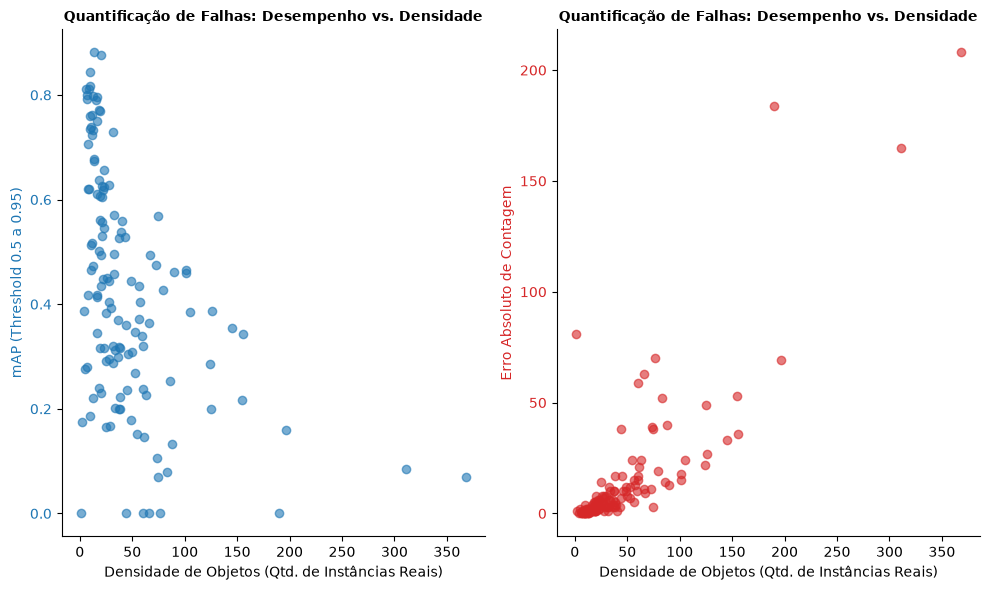

In [44]:
plot_metrics(*evaluate(real_model, real_val_loader, device))